
# ETL con Web Scraping (Yahoo Finance) — Selenium + Pandas + Seaborn

## 0) Requisitos y configuración

In [1]:
import os
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from selenium import webdriver

# Opciones visuales
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 50)
print("Versions → pandas:", pd.__version__)
print("Versions → seaborn:", sns.__version__)

# Carpeta de salidas
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TS = datetime.now().strftime("%Y%m%d-%H%M%S")
TS

Versions → pandas: 2.1.0
Versions → seaborn: 0.13.2


'20251016-172604'

## 1) Parámetros (activos y URLs de Yahoo Finance)

In [2]:

# Construcción de URLs:
# https://finance.yahoo.com/quote/<SIMBOLO>/history/
# - Algunos símbolos requieren encoding: '=' -> %3D, '^' -> %5E
# Ejemplos:
#   ES=F (E-mini S&P 500 futures) -> ES%3DF
#   ^GSPC (S&P 500 index) -> %5EGSPC

tickers = {
    "S&P500 Futures": "https://finance.yahoo.com/quote/ES%3DF/history/",
    "Apple": "https://finance.yahoo.com/quote/AAPL/history/",
    "Bitcoin": "https://finance.yahoo.com/quote/BTC-USD/history/",
}

tickers


{'S&P500 Futures': 'https://finance.yahoo.com/quote/ES%3DF/history/',
 'Apple': 'https://finance.yahoo.com/quote/AAPL/history/',
 'Bitcoin': 'https://finance.yahoo.com/quote/BTC-USD/history/'}

## 2) Extract — Selenium + `pd.read_html(driver.page_source)`

In [3]:

# Configuración mínima de Selenium
options = webdriver.ChromeOptions()
options.page_load_strategy = "none"

driver = webdriver.Chrome(options=options)

dataframes = []

for name, url in tickers.items():
    print(f"Descargando: {name} -> {url}")
    driver.get(url)
    time.sleep(10)  # espera simple para que la tabla se pinte
    driver.save_screenshot("screenshot.png")
    # Extraemos todas las tablas de la página y usamos la primera
    tables = pd.read_html(driver.page_source)
    if not tables:
        print(f"⚠️ No se encontraron tablas para {name}. Revisa la URL o el tiempo de espera.")
        continue

    df = tables[0].copy()
    df["Asset"] = name
    dataframes.append(df)

driver.quit()

len(dataframes), [d.shape for d in dataframes]

Descargando: S&P500 Futures -> https://finance.yahoo.com/quote/ES%3DF/history/


/var/folders/22/0_phxhlx4cs88xh2g_5xldsr0000gn/T/ipykernel_77591/2771941131.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(driver.page_source)


Descargando: Apple -> https://finance.yahoo.com/quote/AAPL/history/


/var/folders/22/0_phxhlx4cs88xh2g_5xldsr0000gn/T/ipykernel_77591/2771941131.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(driver.page_source)


Descargando: Bitcoin -> https://finance.yahoo.com/quote/BTC-USD/history/


/var/folders/22/0_phxhlx4cs88xh2g_5xldsr0000gn/T/ipykernel_77591/2771941131.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(driver.page_source)


(3, [(253, 8), (254, 8), (366, 8)])

## 3) Transform — Limpieza, unión y métricas simples

In [4]:
# Unión de todas las tablas
raw = pd.concat(dataframes, ignore_index=True)
raw['Asset'].value_counts()

Asset
Bitcoin           366
Apple             254
S&P500 Futures    253
Name: count, dtype: int64

In [5]:
# Limpieza y transformación
raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")
data = raw.dropna(subset=["Date"]).copy()

# Renombrado y conversión de tipos
data.columns = ["Date","Open", "High", "Low", "Close", "Adj Close", "Volume","Asset"]

for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

# Ordenado y cálculo de retornos diarios
data = data.sort_values(["Asset", "Date"]).reset_index(drop=True)
if "Close" in data.columns:
    data["Return"] = data.groupby("Asset")["Close"].pct_change()

data.head(10)

/var/folders/22/0_phxhlx4cs88xh2g_5xldsr0000gn/T/ipykernel_77591/840836616.py:15: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  data["Return"] = data.groupby("Asset")["Close"].pct_change()


,Date,Open,High,Low,Close,Adj Close,Volume,Asset,Return
0,2024-10-17,233.43,233.85,230.52,232.15,231.07,32993800.0,Apple,NaN
1,2024-10-18,236.18,236.18,234.01,235.00,233.91,46431500.0,Apple,0.012277
2,2024-10-21,234.45,236.85,234.45,236.48,235.38,36254500.0,Apple,0.006298
3,2024-10-22,233.89,236.22,232.60,235.86,234.77,38846600.0,Apple,-0.002622
4,2024-10-23,234.08,235.14,227.76,230.76,229.69,52287000.0,Apple,-0.021623
5,2024-10-24,229.98,230.82,228.41,230.57,229.50,31109500.0,Apple,-0.000823
6,2024-10-25,229.74,233.22,229.57,231.41,230.34,38802300.0,Apple,0.003643
7,2024-10-28,233.32,234.73,232.55,233.40,232.32,36087100.0,Apple,0.008599
8,2024-10-29,233.10,234.33,232.32,233.67,232.59,35417200.0,Apple,0.001157
9,2024-10-30,232.61,233.47,229.55,230.10,229.03,47070900.0,Apple,-0.015278


## 4) Load — Visualización de tendencias (Seaborn)

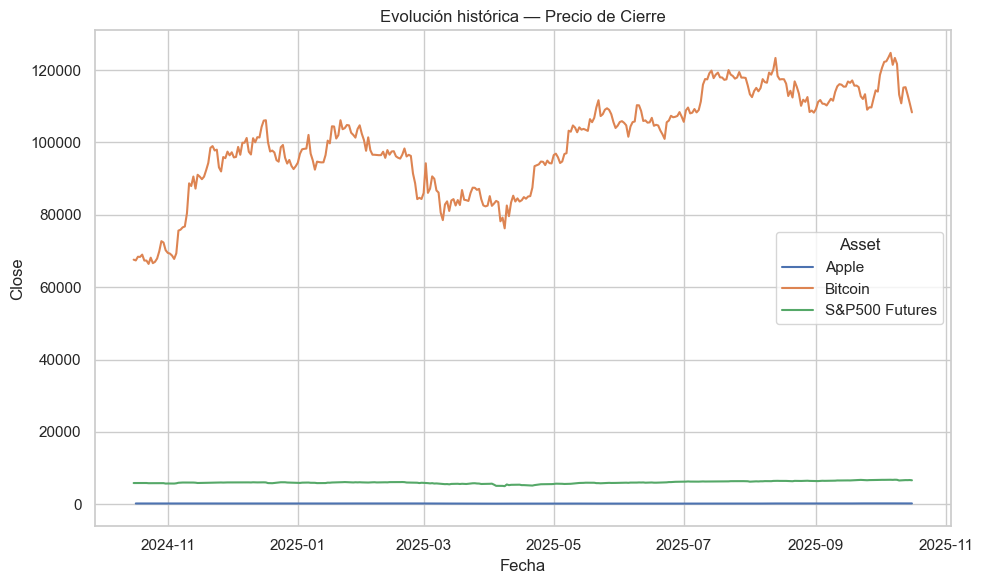

Figura guardada en: outputs/yf_close_20251016-172604.png


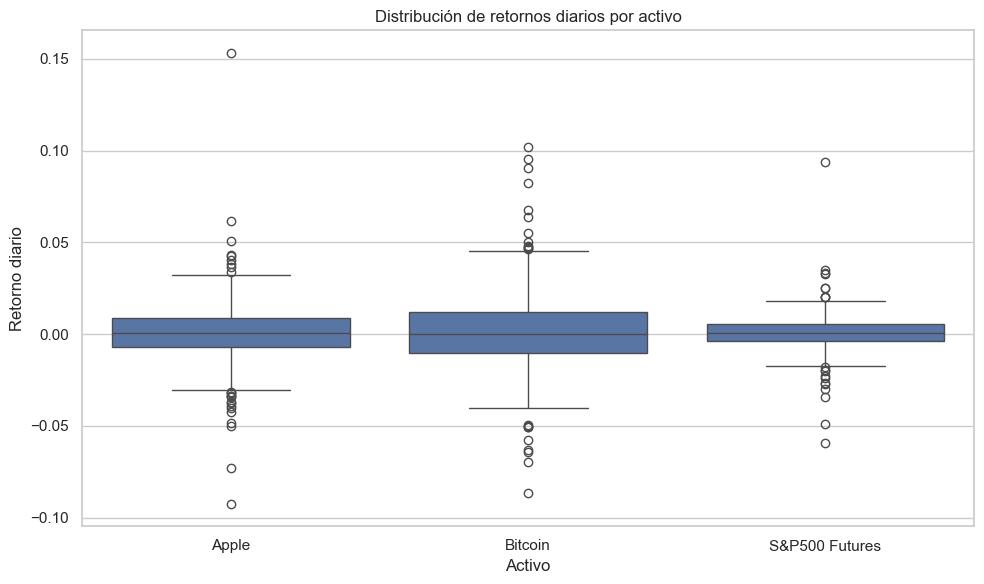

Figura guardada en: outputs/yf_returns_20251016-172604.png


In [6]:

# Gráfico 1: línea del precio de cierre por activo
plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x="Date", y="Close", hue="Asset")
plt.title("Evolución histórica — Precio de Cierre")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.tight_layout()
fig_path_1 = OUTPUT_DIR / f"yf_close_{TS}.png"
plt.savefig(fig_path_1, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", fig_path_1)

# Gráfico 2: distribución de retornos por activo
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="Asset", y="Return")
plt.title("Distribución de retornos diarios por activo")
plt.xlabel("Activo")
plt.ylabel("Retorno diario")
plt.tight_layout()
fig_path_2 = OUTPUT_DIR / f"yf_returns_{TS}.png"
plt.savefig(fig_path_2, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", fig_path_2)


## 5) Export — Guardar resultados a Excel/CSV

In [7]:

excel_path = OUTPUT_DIR / f"yf_history_{TS}.xlsx"

data.to_excel(excel_path, index=False)